In [1]:
import numpy as np

In [2]:
!mamba install scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 4.567 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.5.1      pyhd8ed1ab_0         conda-forge
+ idna                3.19       pyhcf101f3_0         conda-forge
+ joblib              1.5.3      py313h1804a44_3      emscripten-forge-4x
+ narwhals            2.25.0     pyhcf101f3_0         conda-forge
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ requests            2.34.2     pyhcf101f3_0         conda-forge
+ scikit-learn        1.9.0      np23py313hb9816c2_0  emscripten-forge-4x
+ setuptools          84.0.0

In [3]:
!mamba install pandas

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, scikit-learn, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.950 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.5    np23py313h1e705a5_0  emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge


In [4]:
import pandas as pd

In [5]:
data_set=pd.read_csv("insurance.csv",skiprows=1,header=None)

In [6]:
data_set


,0,1,2,3,4,5,6
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [7]:
array_ds=data_set.to_numpy()

for i in range(array_ds.shape[0]):
    if(array_ds[i,1]=="male"):
        array_ds[i,1]=1
    else:
        array_ds[i,1]=0
        
for i in range(array_ds.shape[0]):
    if array_ds[i,4]=="yes":
        array_ds[i,4]=1
    else:
        array_ds[i,4]=0

print(array_ds.dtype)



object


In [8]:
region=np.zeros((1338,4),dtype=int)
Y=np.zeros((1338,1))
for i in range(array_ds.shape[0]):
    if array_ds[i,5]=="northeast":
        region[i,0]=1
        
    elif array_ds[i,5]=="northwest":
        region[i,1]=1
        
    elif array_ds[i,5]=="southeast":
        region[i,2]=1
       
    elif array_ds[i,5]=="southwest":
        region[i,3]=1
    Y[i]=array_ds[i,6]
    
result=np.hstack((array_ds,region))

X=np.delete(result,[5,6],axis=1)
X = np.delete(X, -1, axis=1)

X=X.astype(np.float64)

X.dtype
        

dtype('float64')

In [9]:
rng = np.random.default_rng(42)
perm = rng.permutation(X.shape[0])
X, Y = X[perm], Y[perm]

X_train=X[:937,:]
Y_train=Y[:937]

X_cv=X[937:1136,:]
Y_cv=Y[937:1136]

X_test=X[1136:,:]
Y_test=Y[1136:]




In [10]:
mu=np.mean(X_train,axis=0)
sigma=np.std(X_train,axis=0)

X_train_norm=(X_train-mu)/sigma
X_cv_norm=(X_cv-mu)/sigma
X_test_norm=(X_test-mu)/sigma
print(X_train_norm[0])

[-0.96911199  0.99467798  0.7983516  -0.90221884 -0.49766432 -0.56872342
 -0.58022574  1.67138334]


In [11]:
!mamba install matplotlib

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, scikit-learn, pandas
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.833 seconds
All requested packages already installed.


In [12]:
import matplotlib.pyplot as plt

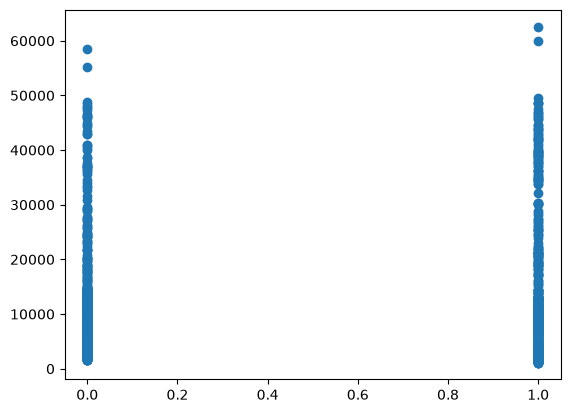

In [13]:
plt.scatter(X_train[:,1],Y_train[:])
plt.show()

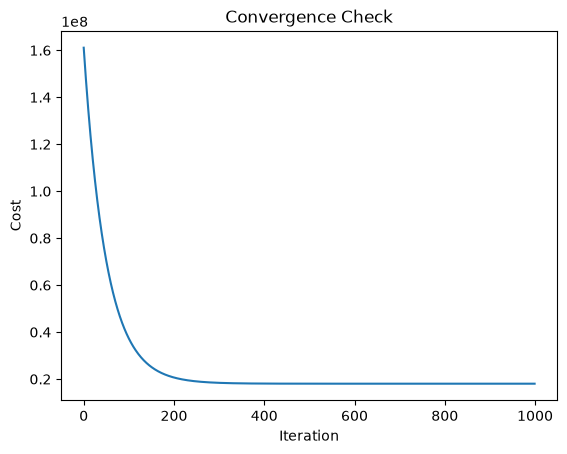

In [14]:
    
def gradient_descent_train(num_iters=1000,alpha=0.01):
    W=np.zeros((X_train_norm.shape[1],))
    b=0.0
    m=X_train_norm.shape[0]
    cost_history=[]
    for i in range(num_iters):
        F=np.dot(X_train_norm,W)+b
        errors=F-Y_train.flatten()
        dJW=(1/m)*np.dot(X_train_norm.T,errors)
        dJb=(1/m)*np.sum(errors)

        W=W-alpha*dJW
        b=b-alpha*dJb

        cost=(1/(2*m))*(np.sum(errors**2))
        cost_history.append(cost)
    return W,b,cost_history

    

W_final, b_final,cost_history = gradient_descent_train()

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Convergence Check")
plt.show()






In [15]:
from sklearn.linear_model import LinearRegression
sk = LinearRegression().fit(X_train_norm, Y_train.flatten())
print("sklearn coefs:", sk.coef_, sk.intercept_)
print("your coefs:   ", W_final, b_final)

sklearn coefs: [3624.30094566   16.23008965 1991.69562532  605.65396408 9564.85043623
  548.7277663   357.04541186 -116.41521218] 13309.514716509064
your coefs:    [3624.21666678   16.55331521 1991.30398763  605.64290488 9564.10591419
  550.03021672  358.26213149 -114.78524705] 13308.940128156317


In [16]:
def predict(X,W,b):
    return np.dot(X,W)+b

In [17]:
def compute_mse(X,Y,W,b):
    m=X.shape[0]
    predictions=predict(X,W,b)
    errors=predictions-Y.flatten()
    return (1/(2*m))*np.sum(errors**2)
    

In [18]:
train_mse = compute_mse(X_train_norm, Y_train, W_final, b_final)
cv_mse    = compute_mse(X_cv_norm, Y_cv, W_final, b_final)
test_mse  = compute_mse(X_test_norm, Y_test, W_final, b_final)

print(f"Training MSE:         {train_mse:,.2f}")
print(f"Cross-Validation MSE: {cv_mse:,.2f}")
print(f"Test MSE:             {test_mse:,.2f}")

Training MSE:         18,028,892.05
Cross-Validation MSE: 20,656,422.99
Test MSE:             17,167,577.33


In [19]:
sk_predictions = sk.predict(X_test_norm)
sk_test_mse = (1/(2*len(Y_test))) * np.sum((sk_predictions - Y_test.flatten())**2)
print("sklearn test MSE:", sk_test_mse)
print("your test MSE:   ", test_mse)

sklearn test MSE: 17167338.974685814
your test MSE:    17167577.333078675


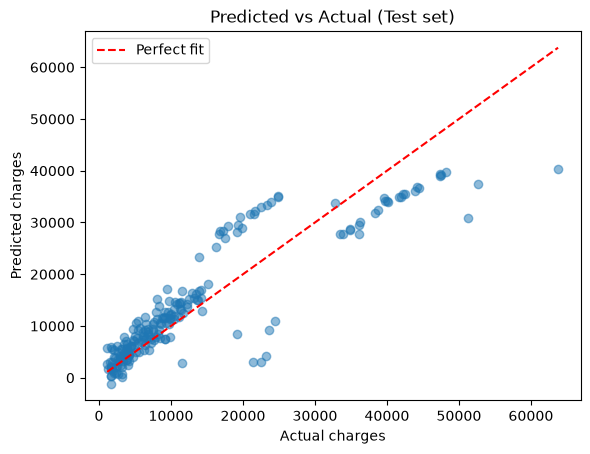

In [20]:
predictions_test = predict(X_test_norm, W_final, b_final)

plt.scatter(Y_test.flatten(), predictions_test, alpha=0.5)
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', label='Perfect fit')
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
plt.title("Predicted vs Actual (Test set)")
plt.legend()
plt.show()